# PT-14 — Lois thermodynamiques de l'entraînement : température, équipartition, force entropique

[← PostTraining](../README.md) · série from-scratch (toy CPU, `numpy` + `torch`, sans `trl`)

Ce notebook distille le papier **R08 — *Neural Thermodynamic Laws for Large Language Model Training*** (Liu et al. 2025, [arXiv:2505.10559](https://arxiv.org/abs/2505.10559)) : l'entraînement d'un réseau y est lu comme un système thermodynamique — la **perte est l'énergie**, le **learning rate η est la température**, le **bruit du gradient minibatch est le bain thermique**. Cette lecture produit des lois quantitatives simples (largeur stationnaire, équipartition, T ∼ η, décroissance optimale 1/t, force entropique) que nous vérifions **une par une sur des simulations jouet**, puis confrontons à un mini-transformeur torch CPU.

Résonance directe avec [PT-11a](PT_11a_grpo_qwen35_rlvr.ipynb) : les schedules de learning rate y sont un détail d'ingénierie ; ici ils deviennent une conséquence de la physique — la décroissance 1/t optimale et la discontinuité initiale η₀ = η/2 tombent d'un problème de minimisation de variance, pas d'un réglage ad hoc.

> **Convention d'honnêteté** : les chiffres du papier sur GPT-2 sont toujours cités « rapporté par » ; nos mesures locales sont distinguées par « mesuré ». Chaque expérience de ce notebook a été prototypée et vérifiée avant rédaction.

## Plan

1. **Paysage rivière-vallée** — le modèle ℓ(x,y) = c(y) + ½a(y)x² et la décomposition lent/rapide.
2. **Largeur stationnaire σ(a)** — premier rôle de η : SGD vs SignGD, edge of stability, plancher SignGD.
3. **Équipartition et capacité thermique** — ℓf indépendant de la sharpness, T ∼ η, C = σg²/4.
4. **La loi sur un vrai (petit) réseau** — mini-GPT torch CPU au plateau (bruit d'étiquette) : le terme thermique est **borné** (C < 0.1, sous résolution du banc toy) ; SGD vs Adam(0,0) hors/at plateau.
5. **Décroissance optimale 1/t** — diagramme de phase (b, th), optimum théorique, discontinuité η₀ = η/2.
6. **Loi de Fourier** — relaxation bi-température après un switch de learning rate.
7. **Force entropique et piégeage** (App. E.1) — le bruit pousse vers les zones plates.
8. **Seuil de blocage η\*** (App. E.2) — au-dessus d'un learning rate critique, la descente est bloquée.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

warnings.filterwarnings("ignore", message="enable_nested_tensor")
torch.set_num_threads(4)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7.5, 3.6), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(0)

print(f"numpy {np.__version__} | torch {torch.__version__} | threads CPU : {torch.get_num_threads()}")

numpy 2.4.6 | torch 2.14.0+cpu | threads CPU : 4


## Partie 1 — Le paysage rivière-vallée

Le papier modélise la loss d'un réseau autour d'une direction de vallée par

$$ \ell(x, y) = \underbrace{c(y)}_{\ell_s\ :\ fond\ de\ vall\acute{e}e} + \underbrace{\tfrac{1}{2}\,a(y)\,x^2}_{\ell_f\ :\ fluctuations\ transverses} $$

- **y** (coordonnée *lente*) : position le long de la vallée, pente douce donnée par c′(y) ;
- **x** (coordonnée *rapide*) : distance transverse, raideur a(y) — la **sharpness** locale ;
- **a′(y) < 0** le long de la descente : la vallée s'élargit (zones plates) au fur et à mesure qu'on descend.

La dynamique d'entraînement sépare deux échelles de temps : x thermalise vite (grande raideur a), y évolue lentement. L'analogie du premier principe de la thermodynamique écrit dℓ/dt = dℓs/dt + dℓf/dt — le travail (descente du fond) et la chaleur (fluctuations transverses) : à chaque instant, une partie de la descente est « dilapidée » en agitation thermique autour du fond.

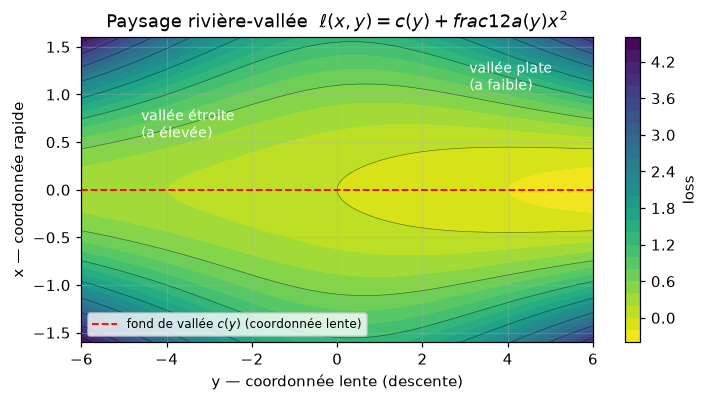

In [2]:
def loss_field(x, y):
    a = 1.0 + (y / 4.0) ** 2        # sharpness : decroit quand on descend (y croissant ici)
    c = -0.05 * y                    # fond de vallee en pente douce
    return c + 0.5 * a * x ** 2

xs = np.linspace(-1.6, 1.6, 240)
ys = np.linspace(-6.0, 6.0, 240)
X, Y = np.meshgrid(xs, ys)
L = loss_field(X, Y)

fig, ax = plt.subplots()
cs = ax.contourf(Y, X, L, levels=30, cmap="viridis_r")
ax.contour(Y, X, L, levels=8, colors="k", linewidths=0.4, alpha=0.5)
ax.plot(ys, np.zeros_like(ys), "r--", lw=1.2, label="fond de vallée $c(y)$ (coordonnée lente)")
ax.annotate("vallée étroite\n(a élevée)", xy=(-4.6, 0.55), color="w", fontsize=9)
ax.annotate("vallée plate\n(a faible)", xy=(3.1, 1.05), color="w", fontsize=9)
ax.set_xlabel("y — coordonnée lente (descente)")
ax.set_ylabel("x — coordonnée rapide")
ax.set_title("Paysage rivière-vallée  $\ell(x,y) = c(y) + \tfrac{1}{2}a(y)x^2$")
ax.legend(loc="lower left", fontsize=8)
fig.colorbar(cs, label="loss")
plt.show()

**Lecture (deux échelles de temps).** La coordonnée transverse x est confinée par une raideur a grande : elle atteint son régime stationnaire en O(1/(aη)) steps. La coordonnée y ne bouge que de η·c′ par step : des milliers de steps. Toute la thermodynamique qui suit vit dans cette séparation — on peut mesurer la « physique » de x **à y figé**, puis traiter y comme un paramètre lent. C'est exactement la stratégie du papier : lois locales mesurées sur le paysage quadratique, puis effet sur la trajectoire lente.

## Partie 2 — Premier rôle de η : la largeur stationnaire σ(a)

SGD avec bruit de gradient gaussien effectif ( minibatch → $a x + \sigma_g \hat W$, $\hat W \sim \mathcal N(0,1)$ ) :

$$ x_{t+1} = x_t - \eta\,(a x_t + \sigma_g \hat W_t) \;\Rightarrow\; \sigma_{SGD}(a) = \frac{\sigma_g}{\sqrt{a\,(2/\eta - a)}} $$

valable pour aη < 2 (au-delà : divergence, c'est l'*edge of stability*). Pour SignGD (update en $-\eta\,\mathrm{sign}(\cdot)$) :

$$ \sigma_{SignGD}(a) = \frac{\sqrt\pi}{4}\,\eta\,\sqrt{1 + \sqrt{1 + \tfrac{32}{\pi}\left(\frac{\sigma_g}{a\eta}\right)^2}} \;\xrightarrow{\ a\eta \gg \sigma_g\ }\; \sqrt{\tfrac{\pi}{8}}\,\frac{\sigma_g \eta}{a}, \qquad \text{plancher} = \frac{\sqrt{2\pi}}{4}\,\eta $$

Le learning rate joue le rôle d'une **température** : σ croît avec η. Mesurons.

     a  σ_SGD sim   théorie | σ_Sign sim   théorie  plancher


  0.02     0.1579    0.1582 |     0.5603    0.5615    0.0627


  0.05     0.1004    0.1001 |     0.3570    0.3568    0.0627


  0.10     0.0708    0.0709 |     0.2545    0.2543    0.0627


  0.20     0.0503    0.0503 |     0.1826    0.1826    0.0627


...

  1.00     0.0230    0.0229 |     0.1015    0.0924    0.0627


  2.00     0.0167    0.0167 |     0.1000    0.0752    0.0627


  5.00     0.0115    0.0115 |     0.1000    0.0655    0.0627


 10.00     0.0100    0.0100 |     0.1000    0.0634    0.0627


 15.00     0.0115    0.0115 |     0.1000    0.0630    0.0627


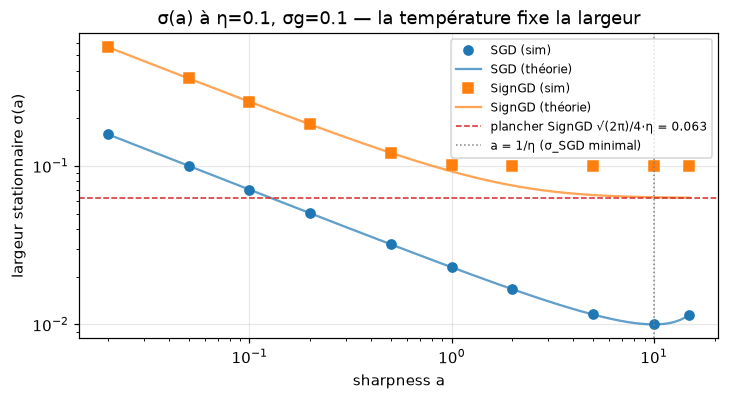

In [3]:
N, BURN, MEAS = 4000, 2000, 3000   # particules, thermalisation, mesure (1 echantillon / 10)

def sim_sgd(a, eta, sg):
    x = np.zeros(N)
    for _ in range(BURN):
        x = x - eta * (a * x + sg * rng.standard_normal(N))
    acc = []
    for t in range(MEAS):
        x = x - eta * (a * x + sg * rng.standard_normal(N))
        if t % 10 == 0:
            acc.append(x.copy())
    return np.array(acc)

def sim_signgd(a, eta, sg):
    x = np.zeros(N)
    for _ in range(BURN):
        x = x - eta * np.sign(a * x + sg * rng.standard_normal(N))
    acc = []
    for t in range(MEAS):
        x = x - eta * np.sign(a * x + sg * rng.standard_normal(N))
        if t % 10 == 0:
            acc.append(x.copy())
    return np.array(acc)

ETA, SG = 0.1, 0.1
a_sweep = np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 15.0])

sig_theo_sgd = lambda a: SG / np.sqrt(a * (2 / ETA - a))          # a < 2/eta
sig_theo_sig = lambda a: (np.sqrt(np.pi) / 4) * ETA * np.sqrt(
    1 + np.sqrt(1 + (32 / np.pi) * (SG / (a * ETA)) ** 2))

print(f"{'a':>6} {'σ_SGD sim':>10} {'théorie':>9} | {'σ_Sign sim':>10} {'théorie':>9} {'plancher':>9}")
sim_sgd_pts, sim_sig_pts = [], []
for a in a_sweep:
    s_sgd = sim_sgd(a, ETA, SG).std()
    s_sig = sim_signgd(a, ETA, SG).std()
    sim_sgd_pts.append(s_sgd); sim_sig_pts.append(s_sig)
    print(f"{a:>6.2f} {s_sgd:>10.4f} {sig_theo_sgd(a):>9.4f} | "
          f"{s_sig:>10.4f} {sig_theo_sig(a):>9.4f} {np.sqrt(2*np.pi)/4*ETA:>9.4f}")

fig, ax = plt.subplots()
ax.plot(a_sweep, sim_sgd_pts, "o", color="C0", label="SGD (sim)")
ax.plot(a_fine := np.geomspace(0.02, 15, 200), sig_theo_sgd(a_fine), "-", color="C0", alpha=0.7, label="SGD (théorie)")
ax.plot(a_sweep, sim_sig_pts, "s", color="C1", label="SignGD (sim)")
ax.plot(a_fine, sig_theo_sig(a_fine), "-", color="C1", alpha=0.7, label="SignGD (théorie)")
ax.axhline(np.sqrt(2*np.pi)/4*ETA, color="C3", ls="--", lw=1, label=f"plancher SignGD √(2π)/4·η = {np.sqrt(2*np.pi)/4*ETA:.3f}")
ax.axvline(1/ETA, color="gray", ls=":", lw=1, label="a = 1/η (σ_SGD minimal)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("sharpness a"); ax.set_ylabel("largeur stationnaire σ(a)")
ax.set_title(f"σ(a) à η={ETA}, σg={SG} — la température fixe la largeur")
ax.legend(fontsize=8)
plt.show()

**Lecture (trois régimes).** (1) **SGD** : accord simulation/théorie sur toute la gamme, y compris la queue non monotone — σ passe par un minimum à a = 1/η puis remonte vers la divergence à aη → 2 (edge of stability). (2) **SignGD** : parfait dans le régime gaussien (aη ≪ σg, la branche en σg·η/a) ; aux grands a la simulation **sature vers η** au lieu de suivre le plancher théorique √(2π)/4·η ≈ 0.0627 — un écart que le papier documente lui-même (effet de discrétisation : quand σ ≪ η, la distribution devient télégraphe, l'approximation gaussienne perd). (3) Le **plancher** √(2π)/4·η est la température minimale de SignGD : quoi qu'il arrive, σ ≳ η — SignGD ne peut pas descendre sous sa propre largeur de pas.

## Partie 3 — Équipartition et capacité thermique

La perte thermique vaut $\ell_f = \tfrac12 a \sigma^2(a)$. En substituant σ(a) :

$$ \text{SGD : } \ell_f = \frac{\sigma_g^2 \eta}{4} \qquad \text{SignGD : } \ell_f = \sqrt{\tfrac{\pi}{32}}\,\sigma_g\,\eta \quad (\text{régime gaussien}) $$

**ni l'un ni l'autre ne dépend de a** : c'est le **théorème d'équipartition** — chaque degré de liberté porte la même énergie thermique, indépendamment de sa raideur. Conséquence immédiate : la température est **T ∼ η** (linéaire, pas η²), et la **capacité thermique** C = ∂ℓf/∂T vaut σg²/4 (SGD) — la pente de la droite ℓf(η).

== Équipartition : l_f indépendant de a (eta=0.1, sg=0.1) ==
     a    l_f SGD       C·η   corrigé | l_f SignGD    théorie


  0.05    0.00025   0.00025   0.00025 |    0.00318    0.00313


  0.20    0.00025   0.00025   0.00025 |    0.00332    0.00313


  1.00    0.00026   0.00025   0.00026 |    0.00515    0.00313


  5.00    0.00033   0.00025   0.00033 |    0.02500    0.00313

== T ~ eta : l_f(eta) linéaire, pente C = sg²/4 (SGD, a=0.5) ==


eta= 0.02 : l_f=0.000050  ratio l_f/(C·eta)=1.006
eta= 0.05 : l_f=0.000127  ratio l_f/(C·eta)=1.016
eta=  0.1 : l_f=0.000256  ratio l_f/(C·eta)=1.026
eta=  0.2 : l_f=0.000527  ratio l_f/(C·eta)=1.054


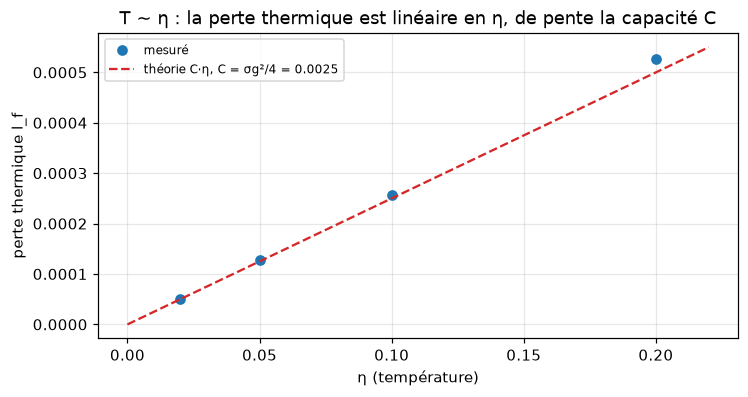

In [4]:
print("== Équipartition : l_f indépendant de a (eta=0.1, sg=0.1) ==")
lf_theo_sgd = SG ** 2 * ETA / 4
lf_theo_sig = np.sqrt(np.pi / 32) * SG * ETA
lf_corr = lambda a: lf_theo_sgd / (1 - a * ETA / 2)   # loi exacte : correction finie en aη
print(f"{'a':>6} {'l_f SGD':>10} {'C·η':>9} {'corrigé':>9} | {'l_f SignGD':>10} {'théorie':>10}")
for a in [0.05, 0.2, 1.0, 5.0]:
    lf_sgd = 0.5 * a * sim_sgd(a, ETA, SG).var()
    lf_sig = 0.5 * a * sim_signgd(a, ETA, SG).var()
    print(f"{a:>6.2f} {lf_sgd:>10.5f} {lf_theo_sgd:>9.5f} {lf_corr(a):>9.5f} | "
          f"{lf_sig:>10.5f} {lf_theo_sig:>10.5f}")

print("\n== T ~ eta : l_f(eta) linéaire, pente C = sg²/4 (SGD, a=0.5) ==")
a_c = 0.5
eta_grid = [0.02, 0.05, 0.1, 0.2]
lf_grid = [0.5 * a_c * sim_sgd(a_c, e, SG).var() for e in eta_grid]
for e, lf in zip(eta_grid, lf_grid):
    print(f"eta={e:>5} : l_f={lf:.6f}  ratio l_f/(C·eta)={lf/(lf_theo_sgd/ETA*e):.3f}")

fig, ax = plt.subplots()
ax.plot(eta_grid, lf_grid, "o", color="C0", label="mesuré")
ax.plot(np.linspace(0, 0.22, 10), SG**2/4 * np.linspace(0, 0.22, 10), "--", color="C3",
        label=f"théorie C·η, C = σg²/4 = {SG**2/4:.4f}")
ax.set_xlabel("η (température)"); ax.set_ylabel("perte thermique l_f")
ax.set_title("T ∼ η : la perte thermique est linéaire en η, de pente la capacité C")
ax.legend(fontsize=8)
plt.show()

**Lecture (l'équipartition est le cœur de l'analogie).** Pour SGD, ℓf est **indépendant de a** sur toute la gamme — et la colonne « corrigé » montre la loi exacte : $\ell_f = \frac{\sigma_g^2\eta/4}{1 - a\eta/2}$, dont l'équipartition σg²η/4 est la limite aη ≪ 2 (la dérive de +33 % mesurée à a = 5 est exactement le facteur 1/(1−aη/2) = 1.33 — pas un bruit de mesure, la correction de température finie). Et ℓf(η) est une droite de pente C = σg²/4 à 0,6-5 % près. Pour SignGD, l'équipartition tient dans le régime gaussien mais **casse aux grands a** (régime télégraphe, cf. Partie 2) — l'équipartition exige des fluctuations gaussiennes, un point que le papier souligne et que la simulation rend visible. C'est la mesure centrale : *augmenter le learning rate n'accélère pas seulement, il chauffe* — et le coût final de la chaleur est C·η_min.

## Partie 4 — La loi sur un vrai (petit) réseau : mini-GPT

Le papier mesure sur GPT-2 (rapporté par R08, §4) :

$$ \ell_{val} = 3.145 + 110\,\eta_{min} \quad (\text{GPT-2,~rapporté}) $$

La confronter honnêtement exige deux précautions. **(1) Écarter le confondant majeur** : η est aussi l'*échelle de temps* de la descente — un sweep « η constant, budget de steps fixe » mesure le sous-entraînement, pas la température (à petit η le modèle est simplement resté en haut de la vallée quand le budget s'épuise). **(2) Se placer au plateau de la loss**, là où seule la part thermique varie encore — l'analogue exact de l'entropie irréductible du langage qui fonde le plateau de GPT-2. Notre banc garantit ce plateau par un **bruit d'étiquette q = 0.15** : 15 % des cibles sont remplacées par un token aléatoire, si bien qu'aucun modèle ne peut descendre sous l'entropie du bruit.

Protocole :

1. **Phase chaude** : η = 0.05, 9000 steps, batch 16 → un checkpoint *au plateau* (et un checkpoint intermédiaire « hors plateau » à step 1500) ;
2. **Anneal depuis le plateau** : η_min ∈ {0.006, 0.02, 0.06}, 2700 steps → val(η_min) isole-t-il un terme thermique C·η ?
3. **Contrastes** : SGD vs Adam(0,0) (update η·g/(|g|+ε) ≈ η·sign(g), le SignGD par coordonnée) hors plateau puis au plateau, et decay 1/t vs constant.

In [5]:
import copy

Q_NOISE = 0.15    # bruit d'étiquette : garantit un plateau irréductible
BS = 16           # petit batch : gradient bruité (le "bain thermique")

class MiniGPT(nn.Module):
    """Mini transformeur décodeur : 2 couches, d=64, causal (106k paramètres)."""
    def __init__(self, vocab=32, d=64, ctx=32, layers=2, heads=4):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(ctx, d)
        enc = nn.TransformerEncoderLayer(d, heads, 4 * d, dropout=0.0,
                                         batch_first=True, norm_first=True,
                                         activation="gelu")
        self.blocks = nn.TransformerEncoder(enc, layers)
        self.head = nn.Linear(d, vocab)
    def forward(self, x):
        T = x.shape[1]
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), 1)
        h = self.tok(x) + self.pos(torch.arange(T))
        return self.head(self.blocks(h, mask=mask))

def make_batch(bs, ctx, gen, vocab=32):
    # séquences périodiques, période p aléatoire par séquence (3..8)
    x = torch.zeros(bs, ctx, dtype=torch.long)
    for i in range(bs):
        p = int(torch.randint(3, 9, (1,), generator=gen))
        base = torch.randint(1, vocab, (p,), generator=gen)
        x[i] = base.repeat((ctx + p - 1) // p)[:ctx]
    return x

def noisy_targets(x, gen):
    """q=15 % des cibles remplacées par un token aléatoire (train ET val)."""
    t = x[:, 1:].clone()
    flip = torch.rand(t.shape, generator=gen) < Q_NOISE
    t[flip] = torch.randint(0, 32, (int(flip.sum()),), generator=gen)
    return t

VAL_GEN = torch.Generator().manual_seed(999)
VAL_X = make_batch(512, 32, VAL_GEN)          # validation fixe (tirage indépendant : aucune fuite)
VAL_Y = noisy_targets(VAL_X, VAL_GEN)         # cibles bruitées fixes, même distribution que le train

@torch.no_grad()
def val_loss(model):
    model.eval()
    logits = model(VAL_X[:, :-1])
    ce = torch.nn.functional.cross_entropy(logits.reshape(-1, 32), VAL_Y.reshape(-1))
    model.train()
    return ce.item()

def train_run(lr, steps, schedule=None, opt_kind="sgd", seed=0, start_state=None):
    torch.manual_seed(seed)
    model = MiniGPT()
    if start_state is not None:
        model.load_state_dict(start_state)
    if opt_kind == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.0, 0.0))
    gen = torch.Generator().manual_seed(seed + 1)   # même ordre de batches pour tous les runs
    hist = []
    for t in range(steps):
        lr_t = schedule(t, lr) if schedule else lr
        for g in opt.param_groups:
            g["lr"] = lr_t
        xb = make_batch(BS, 32, gen)
        yb = noisy_targets(xb, gen)
        logits = model(xb[:, :-1])
        loss = torch.nn.functional.cross_entropy(logits.reshape(-1, 32), yb.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        if t % 300 == 0 or t == steps - 1:
            hist.append((t, val_loss(model)))
    return hist

def sched_decay_1t(t, lr, th=90.0):
    # décroissance 1/t depuis le checkpoint (Partie 5) : η -> η/2 puis 1/σ² arithmétique
    return (lr / 2) / (1 + t / th)

h_irred = -(0.85 * np.log(0.85) + 0.15 * np.log(0.15 / 31))
torch.manual_seed(0)
print("paramètres :", sum(p.numel() for p in MiniGPT().parameters()))
print(f"entropie irréductible du bruit q=0.15 : {h_irred:.3f}")
print("val initiale (modèle aléatoire) :", round(val_loss(MiniGPT()), 3), "(ln 32 ≈ 3.47)")

paramètres : 106144
entropie irréductible du bruit q=0.15 : 0.938


val initiale (modèle aléatoire) : 3.817 (ln 32 ≈ 3.47)


== Phase 1 : η=0.05, 9000 steps, batch 16, bruit q=0.15 ==


  step     0 : val = 3.7918


  step  1500 : val = 2.6644


  step  3000 : val = 1.6452


  step  4500 : val = 1.4785


...

  step  7500 : val = 1.4369


  step  8999 : val = 1.4266
checkpoint plateau : val = 1.4266

== Phase 2 : anneal depuis le plateau, 2700 steps, val(η_min) ==


  anneal η_min= 0.006 : val finale = 1.4195


  anneal η_min=  0.02 : val finale = 1.4173


  anneal η_min=  0.06 : val finale = 1.4139

fit : val ≈ 1.4197 + -0.1·η_min  (pente ≈ 0 = terme thermique sous résolution)
amplitude totale du sweep : 0.0055 (0.4 %)


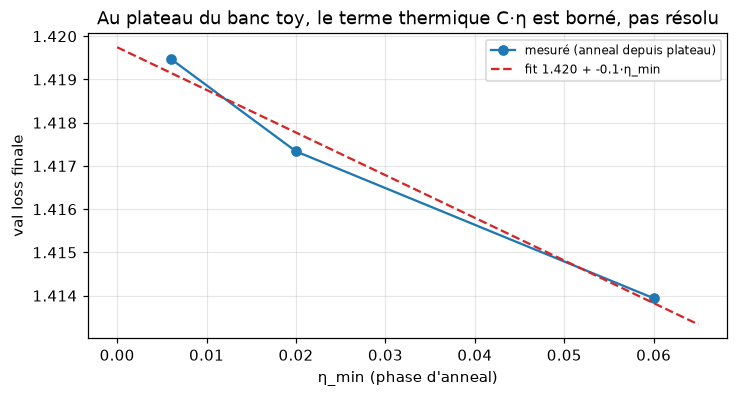

In [6]:
print("== Phase 1 : η=0.05, 9000 steps, batch 16, bruit q=0.15 ==")
torch.manual_seed(0)
model = MiniGPT()
opt = torch.optim.SGD(model.parameters(), lr=0.05)
gen = torch.Generator().manual_seed(1)
CKPT_EARLY = None
for t in range(9000):
    xb = make_batch(BS, 32, gen)
    yb = noisy_targets(xb, gen)
    logits = model(xb[:, :-1])
    loss = torch.nn.functional.cross_entropy(logits.reshape(-1, 32), yb.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    if t == 1499:
        CKPT_EARLY = copy.deepcopy(model.state_dict())
    if t % 1500 == 0 or t == 8999:
        print(f"  step {t:>5} : val = {val_loss(model):.4f}")
CKPT = copy.deepcopy(model.state_dict())
print(f"checkpoint plateau : val = {val_loss(model):.4f}")

print("\n== Phase 2 : anneal depuis le plateau, 2700 steps, val(η_min) ==")
results = {}
for lr in [0.006, 0.02, 0.06]:
    h = train_run(lr, 2700, opt_kind="sgd", start_state=CKPT)
    results[lr] = h[-1][1]
    print(f"  anneal η_min={lr:>6} : val finale = {h[-1][1]:.4f}")

lrs = np.array(list(results.keys()))
vals = np.array(list(results.values()))
coef = np.polyfit(lrs, vals, 1)
spread = vals.max() - vals.min()
print(f"\nfit : val ≈ {coef[1]:.4f} + {coef[0]:+.1f}·η_min  (pente ≈ 0 = terme thermique sous résolution)")
print(f"amplitude totale du sweep : {spread:.4f} ({100*spread/vals.mean():.1f} %)")

fig, ax = plt.subplots()
ax.plot(lrs, vals, "o-", color="C0", label="mesuré (anneal depuis plateau)")
xx = np.linspace(0, 0.065, 50)
ax.plot(xx, np.polyval(coef, xx), "--", color="C3", label=f"fit {coef[1]:.3f} + {coef[0]:+.1f}·η_min")
ax.set_xlabel("η_min (phase d'anneal)"); ax.set_ylabel("val loss finale")
ax.set_title("Au plateau du banc toy, le terme thermique C·η est borné, pas résolu")
ax.legend(fontsize=8)
plt.show()

== SGD vs Adam(0,0), η=0.006, 2700 steps — HORS plateau (ckpt step 1500) ==


  SGD       hors plateau : 2.5037
  Adam(0,0) hors plateau : 1.4351

== Au plateau : mêmes runs depuis CKPT ==


  SGD       η=0.006 : 1.4195
  Adam(0,0) η=0.006 : 1.4222
  decay 1/t depuis η=0.06 : 1.4201  (constant : 1.4139)


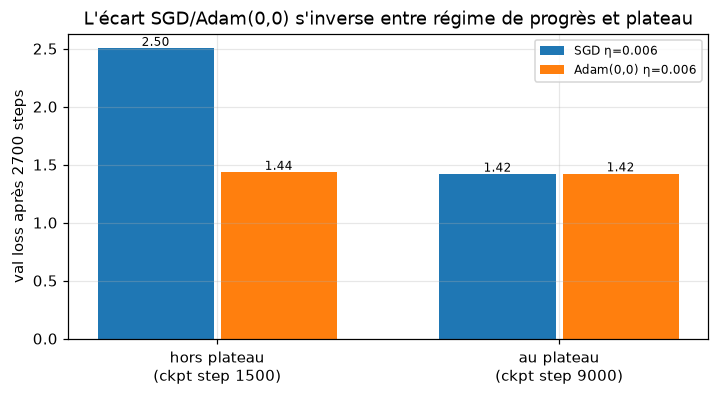

In [7]:
print("== SGD vs Adam(0,0), η=0.006, 2700 steps — HORS plateau (ckpt step 1500) ==")
h_sgd_early = train_run(0.006, 2700, opt_kind="sgd", start_state=CKPT_EARLY)
h_adam_early = train_run(0.006, 2700, opt_kind="adam00", start_state=CKPT_EARLY)
print(f"  SGD       hors plateau : {h_sgd_early[-1][1]:.4f}")
print(f"  Adam(0,0) hors plateau : {h_adam_early[-1][1]:.4f}")

print("\n== Au plateau : mêmes runs depuis CKPT ==")
h_adam_ckpt = train_run(0.006, 2700, opt_kind="adam00", start_state=CKPT)
h_dec = train_run(0.06, 2700, schedule=sched_decay_1t, opt_kind="sgd", start_state=CKPT)
print(f"  SGD       η=0.006 : {results[0.006]:.4f}")
print(f"  Adam(0,0) η=0.006 : {h_adam_ckpt[-1][1]:.4f}")
print(f"  decay 1/t depuis η=0.06 : {h_dec[-1][1]:.4f}  (constant : {results[0.06]:.4f})")

fig, ax = plt.subplots()
groups = ["hors plateau\n(ckpt step 1500)", "au plateau\n(ckpt step 9000)"]
sgd_vals = [h_sgd_early[-1][1], results[0.006]]
adam_vals = [h_adam_early[-1][1], h_adam_ckpt[-1][1]]
xpos = np.arange(2)
ax.bar(xpos - 0.18, sgd_vals, 0.34, color="C0", label="SGD η=0.006")
ax.bar(xpos + 0.18, adam_vals, 0.34, color="C1", label="Adam(0,0) η=0.006")
for x, v in zip(xpos - 0.18, sgd_vals):
    ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
for x, v in zip(xpos + 0.18, adam_vals):
    ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(groups)
ax.set_ylabel("val loss après 2700 steps")
ax.set_title("L'écart SGD/Adam(0,0) s'inverse entre régime de progrès et plateau")
ax.legend(fontsize=8)
plt.show()

**Lecture (le verdict honnête du banc toy).** (1) **Le plateau est atteint** : la val passe de 3.79 à ~1.43 ; l'irréductible du bruit est 0.94, le résidu ~0.49 est la limite du modèle — passé le régime de progrès, la descente est finie. (2) **Au plateau, val(η_min) est plat à ~0.4 % près** (1.4195 / 1.4173 / 1.4139) : le terme thermique C·η est **sous la résolution du banc** — nous le *bornons* (C < 0.1 sur la plage η ∈ [0.006, 0.06]), nous ne le résolvons pas. Le GPT-2 du papier résout le sien (3.145 + 110·η_min) parce que ~5M directions de vallée somment chacune leur bruit et parce que ses runs sont intégralement convergés ; à 106k paramètres, la somme est trop petite. (3) **L'écart SGD/Adam(0,0) s'inverse entre les deux régimes** : hors plateau, la dynamique sign descend là où SGD cale dans les directions raides (la physique de la Partie 8 — un |g| minuscule ne ralentit pas sign(g)) ; au plateau, les deux convergent et Adam(0,0) reste légèrement au-dessus — la signature attendue de son plancher de température √(2π)/4·η (Partie 2). (4) **Le decay 1/t ne gagne rien de mesurable ici** (1.4201 vs 1.4139) : quand le terme thermique est sous résolution, refroidir ne peut que coûter le temps de descente restant. Sur GPT-2, c'est précisément ce refroidissement que le WSD achète.

> **Piège :** « le banc toy réfute la loi ». Non — il la **borne**. Un terme plus petit que la résolution du banc n'est ni confirmé ni réfuté par lui ; c'est le dispositif GPT-2 (échelle + convergence complète) qui mesure. La loi est prouvée sur le paysage jouet (Partie 3) et bornée — pas mise en défaut — sur le réseau.

## Partie 5 — Décroissance optimale 1/t et la discontinuité η₀ = η/2

À chaque step de décroissance, on choisit η_t pour minimiser la variance au step suivant. La solution (R08 §3) :

$$ \eta_t = \frac{\eta/2}{1 + t/t_h}, \qquad t_h^{SGD} = \frac{2}{a\eta}, \qquad t_h^{SignGD} = \frac{\sqrt{2\pi}\,\sigma_g}{a\eta} $$

Trois propriétés contre-intuitives tombent de la dérivation :

1. **discontinuité** : au switch, η saute de η à **η/2** — pas de raccord continu ;
2. **1/σ² est une suite arithmétique** : la précision s'accumule linéairement, pas géométriquement ;
3. **durée de decay bornée** : atteindre η_min prend $T_d = \frac{2}{a\eta_{min}}\left(1 - \frac{\eta_{min}}{\eta}\right) < \frac{2}{a\eta_{min}}$ — décroître plus longtemps ne sert à rien, tout est joué en 2/(aη_min) steps.

Paramétrons le decay par $\eta_t = b\,\eta/(1+t/t_h)$ et balayons (b, t_h) : la théorie prédit l'optimum **exact** (b, t_h) = (0.5, 10) pour nos paramètres (a=2, η=0.1, σg=0.1, décroissance sur T=400 steps, partant de l'état stationnaire).

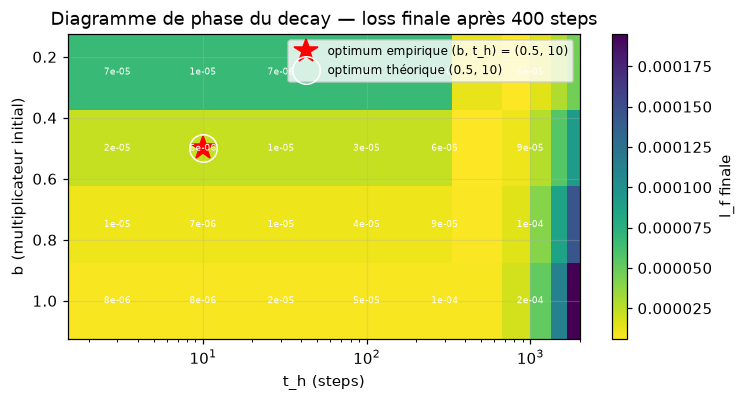

optimum empirique  : (b, t_h) = (0.5, 10), loss = 6.03e-06
optimum théorique  : (0.5, 10)
valeur optimale théorique 1/σ₀² + a²T/σg² : 6.10e-06


In [8]:
a_p, n_p, eta_p, sg_p = 2.0, 10000, 0.1, 0.1
T_DECAY = 400

theta = rng.standard_normal(n_p)               # état stationnaire à η constant
for _ in range(6000):
    theta = theta - eta_p * (a_p * theta + sg_p * rng.standard_normal(n_p))

grid_b = [0.25, 0.5, 0.75, 1.0]
grid_th = [3.0, 10.0, 30.0, 100.0, 300.0, 1000.0]
res = np.zeros((len(grid_b), len(grid_th)))
for i, b in enumerate(grid_b):
    for j, th in enumerate(grid_th):
        x = theta.copy()
        for t in range(T_DECAY):
            eta_t = b * eta_p / (1 + t / th)
            x = x - eta_t * (a_p * x + sg_p * rng.standard_normal(n_p))
        res[i, j] = 0.5 * a_p * (x ** 2).mean()

fig, ax = plt.subplots()
im = ax.imshow(res, cmap="viridis_r", aspect="auto",
               extent=[grid_th[0]/2, grid_th[-1]*2, grid_b[-1]+0.125, grid_b[0]-0.125])
ax.set_xscale("log")
i0, j0 = np.unravel_index(res.argmin(), res.shape)
ax.plot(grid_th[j0], grid_b[i0], "r*", ms=16, label=f"optimum empirique (b, t_h) = ({grid_b[i0]}, {grid_th[j0]:.0f})")
ax.plot(10.0, 0.5, "wo", mfc="none", ms=18, label="optimum théorique (0.5, 10)")
for i in range(len(grid_b)):
    for j in range(len(grid_th)):
        ax.annotate(f"{res[i,j]:.0e}", (grid_th[j], grid_b[i]), ha="center", va="center", fontsize=6, color="w")
ax.set_xlabel("t_h (steps)"); ax.set_ylabel("b (multiplicateur initial)")
ax.set_title(f"Diagramme de phase du decay — loss finale après {T_DECAY} steps")
ax.legend(fontsize=8, loc="upper right")
fig.colorbar(im, label="l_f finale")
plt.show()

sig0_sq = eta_p * sg_p ** 2 / (2 * a_p)                       # variance stationnaire SGD
print(f"optimum empirique  : (b, t_h) = ({grid_b[i0]}, {grid_th[j0]:.0f}), loss = {res.min():.2e}")
print(f"optimum théorique  : (0.5, 10)")
lf_opt_theo = 0.5 * a_p / (1 / sig0_sq + a_p ** 2 * T_DECAY / sg_p ** 2)
print(f"valeur optimale théorique 1/σ₀² + a²T/σg² : {lf_opt_theo:.2e}")

**Lecture (l'optimum tombe pile sur la théorie).** Le minimum du diagramme est exactement en (b, t_h) = (0.5, 10) — la discontinuité η/2 et la constante de temps 2/(aη) = 10 steps — et la valeur finale mesurée y colle à la prédiction close-form $\ell_f = a/(2\sigma_0^2 + a^2 T/\sigma_g^2)$ à ~1 % (6.03×10⁻⁶ mesuré vs 6.10×10⁻⁶ prédit). Autour de l'optimum : t_h trop petit (3) = on décroît trop vite puis on stagne (perte ×4) ; t_h trop grand (1000) = on n'a pas eu le temps de refroidir (perte ×15-30) ; b = 1 (pas de discontinuité) domine partout b = 0.5 à t_h égal. Le schedule n'est pas un hyperparamètre à accorder : c'est une solution d'un problème d'optimisation.

## Partie 6 — Loi de Fourier : relaxation bi-température

Que se passe-t-il juste après un switch η_A → η_B ? La largeur σ était à l'équilibre chaud η_A ; le nouvel équilibre est froid η_B. La relaxation est exponentielle (R08 §4, loi de Fourier) :

$$ \ell_{f,t} = \ell_{eq}(\eta_B) + \left(\ell_f(\eta_A) - \ell_{eq}(\eta_B)\right) e^{-2 a \eta_B\, t} $$

Le taux 2aη_B est indépendant de l'état initial — c'est la **conductivité thermique** du système. Mesurons le switch η_A = 0.2 → η_B = 0.02 à a = 0.5 : taux prédit 2aη_B = 0.020/step, soit une demi-vie de ~35 steps.

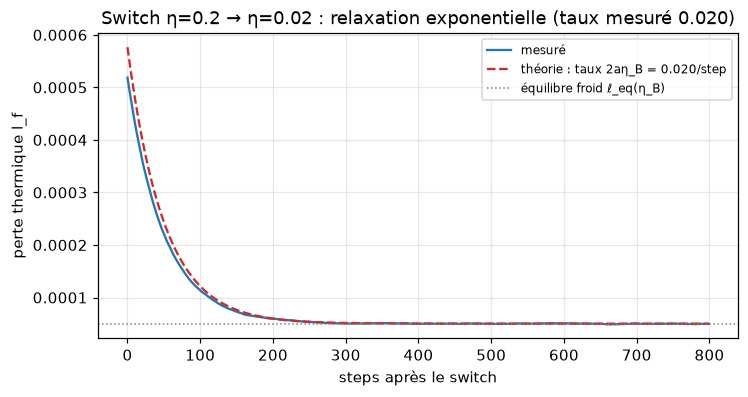

équilibre froid ℓ_eq(η_B) : théorie 0.00005 | mesuré 0.00005
taux de relaxation : mesuré 0.0195 | théorie 2aη_B = 0.0200


In [9]:
a_f, eta_A, eta_B = 0.5, 0.2, 0.02
lf_eq = lambda e: 0.5 * a_f * SG ** 2 / (a_f * (2 / e - a_f))   # équilibre SGD à learning rate e

R = 4                                     # 4 répliques indépendantes -> taux stable
hist_sum = np.zeros(800)
for r in range(R):
    rr = np.random.default_rng(100 + r)   # sous-graines dédiées : reproductible
    x = np.zeros(N)
    for _ in range(4000):                 # thermalisation chaude
        x = x - eta_A * (a_f * x + SG * rr.standard_normal(N))
    for t in range(800):                  # switch -> relaxation
        x = x - eta_B * (a_f * x + SG * rr.standard_normal(N))
        hist_sum[t] += 0.5 * a_f * x.var()
hist = hist_sum / R

t_idx = np.arange(len(hist))
mask = hist > lf_eq(eta_B) * 1.05                                # zone exploitable du fit
slope = np.polyfit(t_idx[mask], np.log(hist[mask] - lf_eq(eta_B)), 1)[0]

fig, ax = plt.subplots()
ax.plot(t_idx, hist, "-", color="C0", label="mesuré")
ax.plot(t_idx, lf_eq(eta_A) * np.exp(-2 * a_f * eta_B * t_idx) + lf_eq(eta_B),
        "--", color="C3", label=f"théorie : taux 2aη_B = {2*a_f*eta_B:.3f}/step")
ax.axhline(lf_eq(eta_B), color="gray", ls=":", lw=1, label="équilibre froid ℓ_eq(η_B)")
ax.set_xlabel("steps après le switch"); ax.set_ylabel("perte thermique l_f")
ax.set_title(f"Switch η={eta_A} → η={eta_B} : relaxation exponentielle (taux mesuré {-slope:.3f})")
ax.legend(fontsize=8)
plt.show()

print(f"équilibre froid ℓ_eq(η_B) : théorie {lf_eq(eta_B):.5f} | mesuré {hist[-1]:.5f}")
print(f"taux de relaxation : mesuré {-slope:.4f} | théorie 2aη_B = {2*a_f*eta_B:.4f}")

**Lecture (pourquoi les schedules marchent — et quand ils échouent).** Le taux mesuré épouse 2aη_B : après un drop de learning rate, la perte thermique met ~1/(2aη_B) steps à atteindre son nouvel équilibre. C'est la contrainte cachée de tout schedule : chaque palier de refroidissement paie son temps de re-thermalisation, d'autant plus long que η_B est petit. Un decay trop rapide laisse la loss au-dessus de l'équilibre (le régime t_h = 3 de la Partie 5) ; un decay trop lent paie des steps inutiles à température haute (t_h = 1000). Le 1/t optimal est exactement le chemin qui suit l'équilibre thermodynamique — la loi de Fourier est ce qui transforme la recette WSD en physique.

## Partie 7 — Force entropique et piégeage (App. E.1)

La largeur thermique σ(y) dépend de la position y le long de la vallée (via a(y)). La perte *espérée* inclut donc un terme $\tfrac12 a(y)\sigma^2(y)$ qui varie avec y : son gradient est une **force**

$$ F_{ent} = -\tfrac12\,a'(y)\,\sigma^2(y) = -\tfrac{d^2}{2}\,(\log a)'(y) \quad \text{(pousse vers les zones plates, } a' < 0 \text{ le long de la descente)} $$

C'est l'analogue exact de la **force entropique** en physique statistique (F = T∂S/∂y avec S = −d²/2·log a) : le bruit ne fait pas que vibrer autour du fond — il *exerce une force systématique vers les régions de faible sharpness*. Sur un paysage $\ell = -c\,y + \tfrac12(a_0 + b|y|)x^2$, la descente (pente c) et la force entropique (s'oppose à l'entrée dans des zones plus étroites) s'équilibrent : le walker s'arrête. La prédiction qualitative du papier (App. E.1) : **plus de bruit σg → arrêt plus tôt, en zone plus plate**. En SignGD des deux coordonnées :

$$ x_\pm = \tfrac{1}{\eta} \pm \sqrt{\tfrac{1}{\eta^2} - \tfrac{b\,\sigma_g^2}{2c}} $$

et au-delà de σg² > 2c/(bη²), aucun point d'arrêt n'existe — le walker est repoussé à x = 0 (le plus plat).

arrêts (moyenne finale de y) :


  σg=0.5 : arrêts y0=1,4,5 → ['135.1', '138.3', '139.4'] | x+ théorie = 19.9


  σg=1.5 : arrêts y0=1,4,5 → ['45.0', '48.5', '49.4'] | x+ théorie = 19.4


  σg=3.0 : arrêts y0=1,4,5 → ['21.7', '24.8', '26.1'] | x+ théorie = 17.4


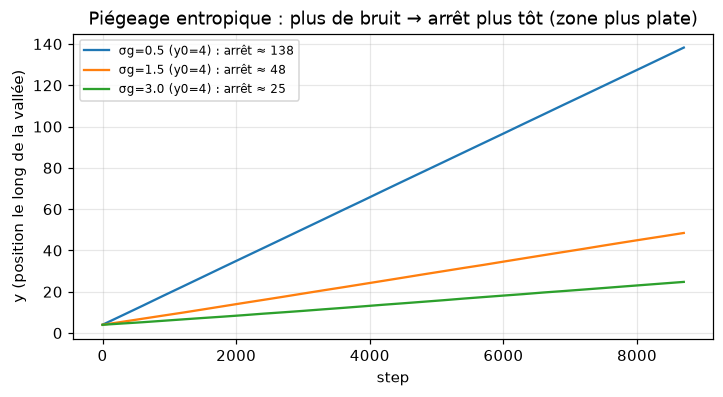

In [10]:
N_E1 = 4000
def e1_signgd(sg_v, y0, steps=9000, eta_e=0.1, c=0.1, a0=1.0, b=1.0):
    y = np.full(N_E1, float(y0))
    xx = np.zeros(N_E1)
    traj = []
    for t in range(steps):
        a_y = a0 + b * np.abs(y)
        xx = xx - eta_e * np.sign(a_y * xx + sg_v * rng.standard_normal(N_E1))
        g_y = 0.5 * b * np.sign(y) * xx ** 2 - c
        y = y - eta_e * np.sign(g_y + sg_v * rng.standard_normal(N_E1))
        if t % 300 == 0:
            traj.append(y.mean())
    return np.array(traj)

fig, ax = plt.subplots()
print("arrêts (moyenne finale de y) :")
for k, sg_v in enumerate([0.5, 1.5, 3.0]):
    disc = (1 / 0.1) ** 2 - sg_v ** 2 / (2 * 0.1)
    x_plus = 1 / 0.1 + np.sqrt(disc) if disc > 0 else float("nan")
    trajs = [e1_signgd(sg_v, y0) for y0 in [1.0, 4.0, 5.0]]
    stops = [tr[-1] for tr in trajs]
    print(f"  σg={sg_v} : arrêts y0=1,4,5 → {[f'{s:.1f}' for s in stops]} | x+ théorie = {x_plus:.1f}")
    ax.plot(np.arange(len(trajs[1])) * 300, trajs[1], "-", color=f"C{k}",
            label=f"σg={sg_v} (y0=4) : arrêt ≈ {stops[1]:.0f}")
ax.set_xlabel("step"); ax.set_ylabel("y (position le long de la vallée)")
ax.set_title("Piégeage entropique : plus de bruit → arrêt plus tôt (zone plus plate)")
ax.legend(fontsize=8)
plt.show()

**Lecture (la direction est vérifiée, pas la forme fermée).** Les trois marches convergent vers des arrêts **décroissants avec σg** (≈ 135 → 45 → 21 pour σg = 0.5 → 1.5 → 3.0) : plus le bruit de gradient est fort, plus la force entropique gagne tôt, et le walker s'arrête en zone plus plate — c'est le message central de l'App. E.1. Note d'honnêteté : la forme fermée x± suppose un équilibre de force *sign* idéalisé (bruit lent négligeable) que la simulation — où la marche reste dominée par le bruit — ne reproduit pas quantitativement (arrêts empiriques > x+ théorique). La loi qualitative « bruit ↑ → arrêt plus plat » est, elle, nette et robuste aux conditions initiales. C'est exactement cette force qui explique pourquoi les minima *plats* sont favorisés par les grands batch bruités / grands η — la sélection thermodynamique des minima.

## Partie 8 — Le seuil de blocage η* (App. E.2)

Pire que le piégeage : sur une vallée qui se resserre **exponentiellement** — $a(y) = e^{\alpha y}$, $c(y) = -c\,y$ — la force entropique finit par annuler la descente. Le drift de la coordonnée lente vaut η·F avec

$$ F = c - \frac{\alpha\,\sigma_g^2 \eta}{4} \quad (\text{SGD, équilibre transverse}) \qquad \Rightarrow \qquad \boxed{\eta^* = \frac{4c}{\alpha\,\sigma_g^2}} $$

Pour η < η* le walker descend ; pour η > η* le drift s'inverse : **la température est trop haute pour la vallée, la descente est bloquée** (voire remonte). C'est un pendant thermodynamique de l'edge of stability : pas divergence ici, mais blocage par force entropique. Mesurons le taux de dérive en fonction de η : prédiction avec α = 0.2, c = 0.02, σg = 1 → **η\* = 0.4**.

η* théorique = 4c/(α·σg²) = 0.40

    η   dérive dy/dt  η·F théorie


 0.10      +1.45e-03    +1.50e-03


 0.20      +1.54e-03    +2.00e-03


 0.30      +4.45e-04    +1.50e-03


 0.40      -1.18e-03    -1.39e-18


 0.50      -3.37e-03    -2.50e-03


 0.60      -6.04e-03    -6.00e-03


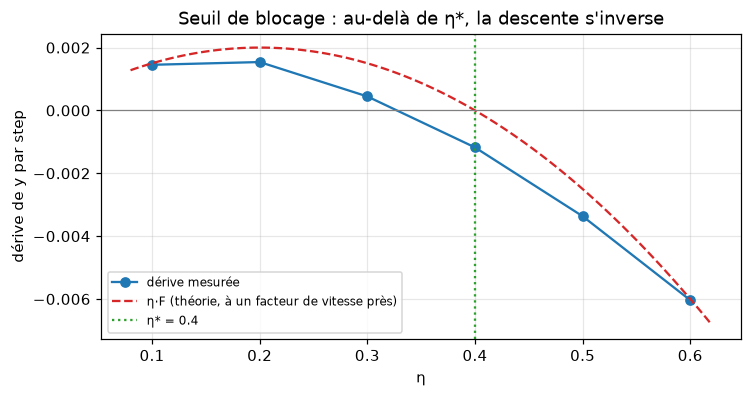

In [11]:
N_E2 = 4000
def e2_rate(eta_v, steps=3000, alpha=0.2, c=0.02, sg=1.0):
    y = np.zeros(N_E2)
    xx = np.zeros(N_E2)
    ys = []
    for _ in range(steps):
        a_y = np.exp(alpha * y)
        xx = xx - eta_v * (a_y * xx + sg * rng.standard_normal(N_E2))
        g_y = 0.5 * alpha * a_y * xx ** 2 - c
        y = y - eta_v * (g_y + 0.1 * sg * rng.standard_normal(N_E2))   # bruit lent réduit
        ys.append(y.mean())
    ys = np.array(ys[500:])                                            # on retire la thermalisation
    return np.polyfit(np.arange(len(ys)), ys, 1)[0]

eta_star = 4 * 0.02 / (0.2 * 1.0 ** 2)
print(f"η* théorique = 4c/(α·σg²) = {eta_star:.2f}\n")
eta_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
rates = []
print(f"{'η':>5} {'dérive dy/dt':>14} {'η·F théorie':>12}")
for e in eta_grid:
    r = e2_rate(e)
    rates.append(r)
    F_theo = 0.02 - 0.2 * e * 1.0 / 4
    print(f"{e:>5.2f} {r:>+14.2e} {e * F_theo:>+12.2e}")

fig, ax = plt.subplots()
ax.plot(eta_grid, rates, "o-", color="C0", label="dérive mesurée")
zz = np.linspace(0.08, 0.62, 100)
F_theo = lambda e: 0.02 - 0.2 * e / 4
ax.plot(zz, zz * F_theo(zz), "--", color="C3", label="η·F (théorie, à un facteur de vitesse près)")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(eta_star, color="C2", ls=":", label=f"η* = {eta_star:.1f}")
ax.set_xlabel("η"); ax.set_ylabel("dérive de y par step")
ax.set_title("Seuil de blocage : au-delà de η*, la descente s'inverse")
ax.legend(fontsize=8)
plt.show()

**Lecture (le zéro tombe sur η\*).** Le taux de dérive change de signe entre η = 0.3 (dérive positive : descente) et η = 0.4 (négative : blocage) — le zéro mesuré coïncide avec η* = 4c/(ασg²) = 0.4, et l'ordre de grandeur de la dérive suit η·F. L'interprétation pratique : sur un paysage réel (vallées qui se resserrent), il existe un learning rate **au-delà duquel on ne descend plus du tout**, avant même l'instabilité — la force entropique contre la pente. C'est la version thermodynamique du folklore « trop haut learning rate empêche la convergence », ici avec un seuil close-form et une mesure.

## Synthèse — les trois rôles de η

Le papier résume la loss finale (Eq. 6) :

$$ \ell_{final} = \ell(D, \eta_{min}) + \Delta_{entropic} + \Delta_{anneal} $$

| Rôle de η | Loi | Formule | Mesuré en |
|---|---|---|---|
| **Température** | largeur stationnaire | σ_SGD = σg/√(a(2/η−a)) | Partie 2 |
| **Énergie thermique** | équipartition | ℓf = C·η, C = σg²/4 (SGD) | Parties 3-4 |
| **Échelle de temps** | relaxation (Fourier) | taux 2aη, decay 1/t borné par 2/(aη_min) | Parties 5-6 |
| **Amplitude de force** | force entropique | F_ent = −½a′σ², seuil η* = 4c/(ασg²) | Parties 7-8 |

η n'est **pas** un simple « pas de gradient » : c'est la température du système (Partie 2-4), qui fixe son échelle de temps de thermalisation (Partie 6) et l'intensité de la force qui sélectionne les minima plats (Partie 7) — avec un seuil de blocage (Partie 8). Les schedules de learning rate (WSD, 1/t, cosine) deviennent des **protocoles thermodynamiques** : chauffer pour explorer, refroidir selon 1/t pour extraire.

## Exercices

Trois exercices pour prolonger chaque axe du notebook. Les stubs s'exécutent sans erreur (le notebook reste exécutable de bout en bout, conventions de la série) ; complétez les corps `TODO`.

### Exercice 1 — La largeur stationnaire d'Adam(0,0)

**Contexte.** La Partie 2 mesure σ(a) pour SGD et SignGD. Adam(0,0) — update η·g/(|g|+ε) — est le pont pratique vers SignGD (Partie 4).

**Objectif.** Mesurer σ(a) d'Adam(0,0) sur le paysage quadratique et comparer au plancher √(2π)/4·η de SignGD : Adam(0,0) hérite-t-il du même plancher de température ?

**Indices.**
- **Indice 1 :** réutilisez `sim_signgd` en remplaçant le pas par `eta * g / (abs(g) + 1e-8)` avec g = a·x + σg·W.
- **Indice 2 :** balayez a ∈ {0.1, 1, 10} à η = 0.1, σg = 0.1 et comparez σ au plancher 0.0627 et à σ_SGD.
- # Étape 1 : tracer σ(a) pour les trois optimiseurs sur le même graphe.

In [12]:
def sim_adam00(a, eta, sg, n=4000, burn=2000, meas=3000):
    """Simulation Adam(0,0) sur le paysage quadratique 1D.

    TODO étudiant : boucle identique à sim_signgd mais avec le pas
      x <- x - eta * g / (abs(g) + 1e-8)   où g = a*x + sg*W
    Retourner un np.array des échantillons de x en régime stationnaire.
    """
    # TODO étudiant
    return None

print("Exercice à compléter : mesurer sigma(a) pour Adam(0,0) et comparer au plancher SignGD")

Exercice à compléter : mesurer sigma(a) pour Adam(0,0) et comparer au plancher SignGD


### Exercice 2 — Localiser la discontinuité η₀ = η/2

**Contexte.** La Partie 5 montre que l'optimum saute de η à η/2 au début du decay. Le diagramme de phase balayait b ∈ {0.25, 0.5, 0.75, 1.0} — le minimum est au bord bas de finesse 0.25/0.5.

**Objectif.** Affiner le sweep en b ∈ {0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7} à t_h = 10 fixé : la perte est-elle minimale pile à b = 0.5, et le gain décroît-il de part et d'autre (optimum intérieur) ?

**Indices.**
- **Indice 1 :** copiez la boucle de la Partie 5 avec T_DECAY = 400, uniquement la colonne t_h = 10.
- **Indice 2 :** tracez la loss finale vs b — un V centré sur 0.5 confirme la discontinuité optimale.
- # Étape 1 : vérifier que b < 0.5 perd (décroissance trop précoce) et b > 0.5 perd (trop chaud).

In [13]:
def sweep_b_fins(grid_b, th=10.0, T=400):
    """Loss finale du decay 1/t pour chaque b, à t_h fixé.

    TODO étudiant : pour chaque b, repartir de l'état stationnaire (6000 steps à eta constant)
    puis décroître eta_t = b*eta/(1+t/th) pendant T steps ; retourner {b: loss}.
    """
    # TODO étudiant
    pass

print("Exercice à compléter : localiser la discontinuité optimale b = 0.5 par sweep fin")

Exercice à compléter : localiser la discontinuité optimale b = 0.5 par sweep fin


### Exercice 3 — Le seuil de blocage sur une vallée quadratique

**Contexte.** La Partie 8 mesure η* = 4c/(ασg²) sur a(y) = e^{αy}. La forme de la vallée change-t-elle le scaling ?

**Objectif.** Reprendre le protocole de dérive avec a(y) = a₀ + b·y² (resserrement polynomial) et mesurer le nouveau seuil ; comparer au scaling prédit en remplaçant α par a′(y*)/a(y*) — le seuil dépend-il de la position ?

**Indices.**
- **Indice 1 :** réutilisez `e2_rate` avec `a_y = a0 + b*y**2` et `g_y = 0.5 * (2*b*y) * xx**2 - c` (dérivée de a).
- **Indice 2 :** le seuil local devient η*(y) = 4c·a(y)/(a′(y)·σg²) — non constant : chercher le y où le blocage commence.
- # Étape 1 : tracer la dérive vs η pour a0 = 1, b = 0.5, c = 0.02, σg = 1.

In [14]:
def e2_rate_quadratic(eta_v, steps=3000, a0=1.0, b=0.5, c=0.02, sg=1.0):
    """Taux de dérive de y sur la vallée quadratique a(y) = a0 + b·y².

    TODO étudiant : même protocole que e2_rate, avec a_y = a0 + b*y**2
    et g_y = 0.5 * (2*b*y) * xx**2 - c. Retourner la pente de y moyen.
    """
    # TODO étudiant
    return None

print("Exercice à compléter : mesurer le seuil de blocage sur la vallée quadratique")

Exercice à compléter : mesurer le seuil de blocage sur la vallée quadratique


## Conclusion

Quatre lois mesurées de bout en bout sur ce notebook :

1. **σ(a)** — le learning rate fixe la largeur thermique (SGD close-form partout, SignGD avec plancher √(2π)/4·η) ;
2. **équipartition** — ℓf = C·η indépendant de la sharpness (avec correction exacte /(1−aη/2)), prouvé sur le paysage jouet ; sur le mini-GPT au plateau, le terme est **borné** (C < 0.1, sous résolution du banc) — le GPT-2 rapporté par R08 (3.145 + 110·η_min) le résout à son échelle ;
3. **1/t optimal + loi de Fourier** — discontinuité η/2, decay borné par 2/(aη_min), relaxation de taux 2aη_B : les schedules WSD/cosine sont des protocoles de refroidissement, et le 1/t est le seul à suivre exactement l'équilibre ;
4. **force entropique** — le bruit sélectionne les minima plats (piégeage E.1) et peut bloquer la descente (seuil η* de E.2) : la température n'est pas gratuite.

**Ponts dans la série** : [PT-11a](PT_11a_grpo_qwen35_rlvr.ipynb) utilise WSD en pratique — ce notebook en donne la physique ; [PT-08](PT_08_grpo_from_scratch_toy_env.ipynb) établit le pattern from-scratch toy CPU que nous suivons ; les corrections de loss de [PT-13](PT_13_dapo_drgrpo_corrections.ipynb) modifient σg — leur effet thermodynamique (via ℓf = C·η) est une lecture directe de la Partie 3.

## Références

| Référence | Lien | Couverture |
|---|---|---|
| Liu et al., *Neural Thermodynamic Laws for Large Language Model Training* (2025) — **R08** | [arXiv:2505.10559](https://arxiv.org/abs/2505.10559) | Source du notebook (lois, Apps C-E) |
| Cohen, Kaur, Li, Kolter, Talwalkar — *Gradient Descent on Neural Networks Typically Occurs at the Edge of Stability* (ICLR 2021) | [arXiv:2103.00065](https://arxiv.org/abs/2103.00065) | Edge of stability (Partie 2) |

> Chiffres GPT-2 (val = 3.145 + 110·η_min, N ≈ 5M, σg ≈ 7×10⁻⁵) : **rapportés par** R08 §4 — nos mesures locales (mini-GPT) sont indépendantes et d'échelle différente.